# ResNet-18: Pretrained Inference + Feature Map Visualization

**Goal:** Load a pretrained ResNet-18, run inference on a real image, read top-5 predictions, then strip the classification head and visualize what the first conv layer actually learned to detect.

**What's different from the MLP project:**
- MLP project: built a model from scratch, trained it for 5 epochs on MNIST
- This project: load weights someone else already trained (ImageNet, 1.2M images), inference only — no training loop

**Notebook outline:**
1. Imports
2. Load a test image
3. Preprocess (fulfill the model's input contract)
4. Load pretrained ResNet-18
5. Run inference → top-5 predictions
6. Strip the classification head → extract feature maps from layer 1
7. Visualize the feature maps

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print('PyTorch version:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.8.0+cpu
Device: cpu


## Load & Preprocess the Image

ResNet-18 has an input contract: RGB image, 224×224, normalized to ImageNet mean/std.  
Raw pixels won't work — we must fulfill this contract before inference.

In [2]:
# Load image
img = Image.open('data/Amy.jpg').convert('RGB')
print('Original PIL image size (W, H):', img.size)

# Preprocessing pipeline — ResNet-18's input contract
preprocess = transforms.Compose([
    transforms.Resize(256),           # resize shorter side to 256
    transforms.CenterCrop(224),       # crop center 224x224
    transforms.ToTensor(),            # PIL -> tensor, scales to [0.0, 1.0]
    transforms.Normalize(             # ImageNet mean/std — baked into all pretrained models
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

img_tensor = preprocess(img)
print('After preprocess (no batch):', img_tensor.shape)  # (3, 224, 224)

img_batch = img_tensor.unsqueeze(0)
print('After unsqueeze (with batch):', img_batch.shape)  # (1, 3, 224, 224)

Original PIL image size (W, H): (711, 1263)
After preprocess (no batch): torch.Size([3, 224, 224])
After unsqueeze (with batch): torch.Size([1, 3, 224, 224])


## Load Pretrained ResNet-18

`torchvision.models` ships pretrained weights trained on ImageNet (1.2M images, 1000 classes).  
We set `eval()` to disable Dropout and switch BatchNorm to use stored running stats.

In [3]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.eval()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"ResNet-18 total parameters: {total_params:,}")
print(f"Model is in training mode: {model.training}")

ResNet-18 total parameters: 11,689,512
Model is in training mode: False


## Run Inference — Top-5 Predictions

Forward pass only — no gradients needed. `torch.no_grad()` stops PyTorch from building the computation graph, saving memory and time.

In [4]:
with torch.no_grad():
    logits = model(img_batch)

print("Output shape:", logits.shape)  # (1, 1000)

# Convert logits to probabilities
probs = torch.softmax(logits, dim=1)

# Top-5 predictions
top5_probs, top5_indices = torch.topk(probs, k=5)

# Get human-readable class names from the weights metadata
categories = weights.meta["categories"]

print("\nTop-5 predictions for Amy:")
for i in range(5):
    label = categories[top5_indices[0][i]]
    prob = top5_probs[0][i].item() * 100
    print(f"  {i+1}. {label:<30} {prob:.2f}%")

Output shape: torch.Size([1, 1000])

Top-5 predictions for Amy:
  1. tabby                          59.12%
  2. Egyptian cat                   16.32%
  3. tiger cat                      7.61%
  4. Persian cat                    3.45%
  5. quilt                          2.84%


## Extract Feature Maps from Layer 1

We want to see what the first conv layer detects — edges, colors, textures.  
A **forward hook** intercepts the layer's output mid-forward-pass without modifying the model.

In [5]:
# Storage for the hook to write into
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps["layer1"] = output.detach()  # detach from computation graph

# Attach hook to the first conv layer
hook = model.layer1.register_forward_hook(hook_fn)

# Run forward pass — hook fires automatically
with torch.no_grad():
    _ = model(img_batch)

# Remove hook — good practice, don't leave listeners dangling
hook.remove()

print("Feature map shape:", feature_maps["layer1"].shape)
# Expected: (1, 64, 56, 56) — batch=1, 64 filters, 56x56 spatial

Feature map shape: torch.Size([1, 64, 56, 56])


## Visualize Feature Maps

Each of the 64 filters detects a different pattern — edges, colors, textures.  
We'll plot the first 32 as a grid so you can see what layer1 actually learned to look for.

Feature maps shape (no batch): torch.Size([64, 56, 56])


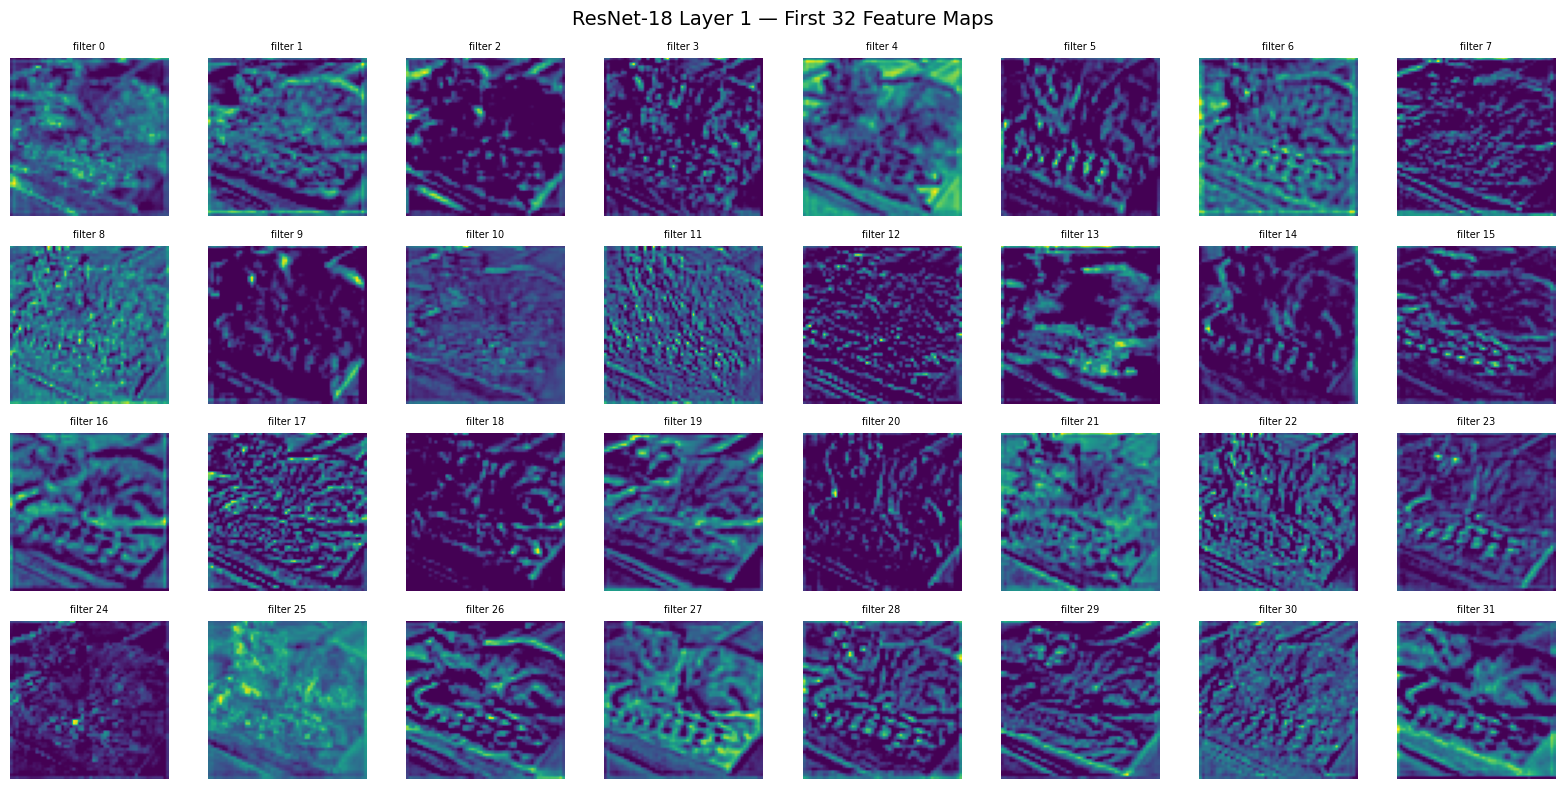

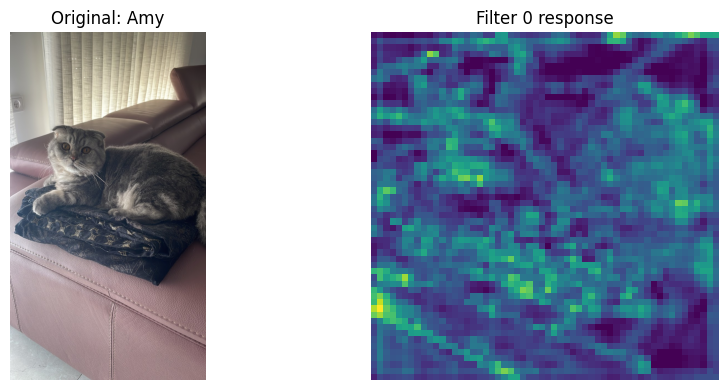

In [6]:
fmaps = feature_maps["layer1"][0]  # remove batch dim → (64, 56, 56)
print("Feature maps shape (no batch):", fmaps.shape)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("ResNet-18 Layer 1 — First 32 Feature Maps", fontsize=14)

for i, ax in enumerate(axes.flat):
    fmap = fmaps[i].numpy()
    ax.imshow(fmap, cmap="viridis")
    ax.set_title(f"filter {i}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Also show the original image alongside for comparison
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
axes2[0].imshow(img)
axes2[0].set_title("Original: Amy")
axes2[0].axis("off")
axes2[1].imshow(fmaps[0].numpy(), cmap="viridis")
axes2[1].set_title("Filter 0 response")
axes2[1].axis("off")
plt.tight_layout()
plt.show()